# Prática 6 de Random Forest e várias técnicas de Boost  (Comitê ou Ensemble).



### **Questão 1** Modifique o exemplo abaixo para 1000 amostras, dispersão 1.3 e observe a diferença visual das três técnicas: Knn, Random Forest e XGBoost

In [ ]:
#@title Comparando KNN, Random Forest e XGBoost (3 atributos, gráficos 2D pares)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from ipywidgets import widgets
from IPython.display import display, clear_output
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# XGBoost
from xgboost import XGBClassifier

# Variáveis globais
X = None
y = None
X_train = None
X_test = None
y_train = None
y_test = None
accuracy = None
classifier = None
output_widget = widgets.Output()

# Criar widgets
classifier_selector = widgets.Dropdown(
    options=['KNN', 'Random Forest', 'XGBoost'],
    value='KNN',
    description='Classificador:'
)
k_slider = widgets.IntSlider(min=1, max=15, value=3, description='K:')
n_samples_slider = widgets.IntSlider(min=10, max=2000, value=1000, description='Amostras:')
spread_slider = widgets.FloatSlider(min=0.5, max=5.0, value=1.3, step=0.1, description='Dispersão:')
test_size_slider = widgets.FloatSlider(min=0.1, max=0.5, value=0.2, step=0.05, description='% Teste:')
predict_button = widgets.Button(description='Avaliar Modelo')
new_data_button = widgets.Button(description='Gerar Novo Dataset')

controls_top = widgets.HBox([classifier_selector, k_slider, n_samples_slider, spread_slider, test_size_slider])
controls_bottom = widgets.HBox([predict_button, new_data_button])

def generate_dataset():
    global X, y, X_train, X_test, y_train, y_test
    n_samples = n_samples_slider.value
    spread = spread_slider.value
    test_size = test_size_slider.value

    # Gerar dados com 3 atributos
    X, y = make_blobs(n_samples=n_samples, centers=2, n_features=3,
                      cluster_std=spread, center_box=(-4, 4), random_state=None)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    return X_train, X_test, y_train, y_test

def create_classifier():
    global classifier
    if classifier_selector.value == 'KNN':
        classifier = KNeighborsClassifier(n_neighbors=k_slider.value)
    elif classifier_selector.value == 'Random Forest':
        classifier = RandomForestClassifier(n_estimators=100, random_state=42)
    elif classifier_selector.value == 'XGBoost':
        classifier = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

def plot_decision_regions():
    global classifier
    with output_widget:
        clear_output(wait=True)
        plt.figure(figsize=(16, 5))

        if classifier is None:
            create_classifier()
            classifier.fit(X_train, y_train)

        # Três pares de atributos
        pairs = [(0,1), (0,2), (1,2)]
        titles = ["Atributos (X0 vs X1)", "Atributos (X0 vs X2)", "Atributos (X1 vs X2)"]

        for idx, (i, j) in enumerate(pairs):
            plt.subplot(1, 3, idx+1)

            # grid para regiões de decisão
            x_min, x_max = X[:, i].min() - 1, X[:, i].max() + 1
            y_min, y_max = X[:, j].min() - 1, X[:, j].max() + 1
            xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                                 np.arange(y_min, y_max, 0.1))

            Z = classifier.predict(np.c_[xx.ravel(), yy.ravel(),
                                         np.full(xx.ravel().shape, X[:, 3-i-j].mean())])
            Z = Z.reshape(xx.shape)

            plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
            plt.contour(xx, yy, Z, cmap=plt.cm.RdYlBu)

            # pontos treino
            plt.scatter(X_train[y_train==0, i], X_train[y_train==0, j],
                        c='blue', marker='o', label='Classe 0 (Treino)')
            plt.scatter(X_train[y_train==1, i], X_train[y_train==1, j],
                        c='red', marker='o', label='Classe 1 (Treino)')
            # pontos teste
            plt.scatter(X_test[y_test==0, i], X_test[y_test==0, j],
                        c='lightblue', marker='s', label='Classe 0 (Teste)')
            plt.scatter(X_test[y_test==1, i], X_test[y_test==1, j],
                        c='lightcoral', marker='s', label='Classe 1 (Teste)')

            plt.title(titles[idx])
            plt.grid(True)

        if accuracy is not None:
            plt.suptitle(f"Acurácia: {accuracy:.2%} | "
                         f"Classificador: {classifier_selector.value}, "
                         f"K={k_slider.value if classifier_selector.value=='KNN' else 'N/A'}")

        plt.tight_layout()
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.show()

def make_prediction(b):
    global accuracy
    if X_train is None:
        generate_new_data(None)
        return
    create_classifier()
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    plot_decision_regions()

def generate_new_data(b):
    generate_dataset()
    plot_decision_regions()

def update_k(change):
    if X_train is not None and classifier_selector.value == 'KNN':
        make_prediction(None)

def update_params(change):
    if X is not None:
        generate_new_data(None)

predict_button.on_click(make_prediction)
new_data_button.on_click(generate_new_data)
k_slider.observe(update_k, names='value')
classifier_selector.observe(update_k, names='value')
n_samples_slider.observe(update_params, names='value')
spread_slider.observe(update_params, names='value')
test_size_slider.observe(update_params, names='value')

display(controls_top)
display(controls_bottom)
display(output_widget)

# dataset inicial
generate_new_data(None)


Output()

### **Tarefa 1**

Complete a tabela para dataset sintéticos com dificuldade **Média**, executando o código abaixo.


Amostras | Tecnica | Classes  | Atributos | Acurácia | Tempo de Execução
--|--|--|--|--|--
50000 | KNN K=3 | 2 | 6 |
50000 | Random Forest 5 Arvore e Prof 3 | 2 |6 |
50000 | Random Forest 10 Arvore e Prof 3 | 2 |6 |
50000 | Random Forest 5 Arvore e Prof 10 | 2 | 6 |
50000 | Random Forest 10 Arvore e Prof 3  | 4 | 12 |
50000 | XGboost 5 Arvore e Prof 10 | 4 | 12 |
50000 | Ada boost 10  | 4 | 12 |
50000 | Ada boosto 20 | 4 | 12 |
50000 | Gradient Boost 10 árvores e prof 5 | 4 | 12 |




In [ ]:
#@title Demonstração KNN vs Modelos baseados em árvore (Random Forest, AdaBoost, GradientBoosting, XGBoost)
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import time
from IPython.display import clear_output
import ipywidgets as widgets
from IPython.display import display

# XGBoost
from xgboost import XGBClassifier

# Widgets de parâmetros do dataset
n_samples_slider = widgets.IntSlider(value=1000, min=1000, max=100000, step=1000,
                                     description='Nº Amostras:', style={'description_width': 'initial'})
n_classes_slider = widgets.IntSlider(value=2, min=2, max=10, step=1,
                                     description='Nº Classes:', style={'description_width': 'initial'})
n_features_slider = widgets.IntSlider(value=2, min=2, max=20, step=1,
                                      description='Nº Atributos:', style={'description_width': 'initial'})
test_size_slider = widgets.FloatSlider(value=0.2, min=0.1, max=0.9, step=0.1,
                                       description='% Teste:', style={'description_width': 'initial'})
difficulty_dropdown = widgets.Dropdown(
    options=[('Fácil', 1), ('Médio', 2), ('Difícil', 3), ('Muito Difícil', 4)],
    value=1, description='Dificuldade:', style={'description_width': 'initial'})

# Widgets para KNN
k_neighbors_slider = widgets.IntSlider(value=3, min=1, max=20, step=1,
                                       description='K (KNN):', style={'description_width': 'initial'})

# Widgets para modelos de árvore
n_estimators_slider = widgets.IntSlider(value=10, min=5, max=50, step=1,
                                        description='Nº Árvores:', style={'description_width': 'initial'})
max_depth_slider = widgets.IntSlider(value=5, min=1, max=20, step=1,
                                     description='Profundidade max.:', style={'description_width': 'initial'})

# Escolha de algoritmo
algorithm_dropdown = widgets.Dropdown(
    options=['KNN', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost', 'Todos'],
    value='Todos',
    description='Algoritmo:',
    style={'description_width': 'initial'}
)

evaluate_button = widgets.Button(description='Avaliar', button_style='success')
output = widgets.Output()

def create_and_evaluate_model(b):
    with output:
        clear_output()

        # Gerar dataset
        print("Gerando dataset...")
        X, y = make_classification(
            n_samples=n_samples_slider.value,
            n_classes=n_classes_slider.value,
            n_features=n_features_slider.value,
            n_redundant=0,
            n_informative=n_features_slider.value,
            random_state=1,
            n_clusters_per_class=1,
            class_sep=1.0/difficulty_dropdown.value
        )

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size_slider.value, random_state=42)

        results = {}

        # KNN
        if algorithm_dropdown.value in ['KNN', 'Todos']:
            print("\nTreinando modelo KNN...")
            start = time.time()
            knn = KNeighborsClassifier(n_neighbors=k_neighbors_slider.value)
            knn.fit(X_train, y_train)
            pred = knn.predict(X_test)
            acc = accuracy_score(y_test, pred)
            results['KNN'] = {'accuracy': acc, 'time': time.time()-start, 'k': k_neighbors_slider.value}

        # Random Forest
        if algorithm_dropdown.value in ['Random Forest', 'Todos']:
            print("\nTreinando modelo Random Forest...")
            start = time.time()
            rf = RandomForestClassifier(n_estimators=n_estimators_slider.value,
                                        max_depth=max_depth_slider.value, random_state=42)
            rf.fit(X_train, y_train)
            pred = rf.predict(X_test)
            acc = accuracy_score(y_test, pred)
            results['Random Forest'] = {'accuracy': acc, 'time': time.time()-start,
                                        'n_estimators': n_estimators_slider.value,
                                        'depth': max_depth_slider.value}

        # AdaBoost
        if algorithm_dropdown.value in ['AdaBoost', 'Todos']:
            print("\nTreinando modelo AdaBoost...")
            start = time.time()
            ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=max_depth_slider.value),
    n_estimators=n_estimators_slider.value, random_state=42
)
            ada.fit(X_train, y_train)
            pred = ada.predict(X_test)
            acc = accuracy_score(y_test, pred)
            results['AdaBoost'] = {'accuracy': acc, 'time': time.time()-start,
                                   'n_estimators': n_estimators_slider.value,
                                   'depth': max_depth_slider.value}

        # Gradient Boosting
        if algorithm_dropdown.value in ['Gradient Boosting', 'Todos']:
            print("\nTreinando modelo Gradient Boosting...")
            start = time.time()
            gb = GradientBoostingClassifier(n_estimators=n_estimators_slider.value,
                                            max_depth=max_depth_slider.value, random_state=42)
            gb.fit(X_train, y_train)
            pred = gb.predict(X_test)
            acc = accuracy_score(y_test, pred)
            results['Gradient Boosting'] = {'accuracy': acc, 'time': time.time()-start,
                                            'n_estimators': n_estimators_slider.value,
                                            'depth': max_depth_slider.value}

        # XGBoost
        if algorithm_dropdown.value in ['XGBoost', 'Todos']:
            print("\nTreinando modelo XGBoost...")
            start = time.time()
            xgb = XGBClassifier(n_estimators=n_estimators_slider.value,
                                max_depth=max_depth_slider.value,
                                use_label_encoder=False, eval_metric='logloss', random_state=42)
            xgb.fit(X_train, y_train)
            pred = xgb.predict(X_test)
            acc = accuracy_score(y_test, pred)
            results['XGBoost'] = {'accuracy': acc, 'time': time.time()-start,
                                  'n_estimators': n_estimators_slider.value,
                                  'depth': max_depth_slider.value}

        # Resultados
        print("\nResultados:")
        print(f"Número de amostras: {n_samples_slider.value}")
        print(f"Número de classes: {n_classes_slider.value}")
        print(f"Número de atributos: {n_features_slider.value}")
        print(f"Porcentagem de teste: {test_size_slider.value*100}%")
        print(f"Nível de dificuldade: {difficulty_dropdown.label}")

        for model, metrics in results.items():
            print(f"\n{model}:")
            print(f"Acurácia: {metrics['accuracy']:.4f}")
            print(f"Tempo de execução: {metrics['time']:.2f}s")
            if model == 'KNN':
                print(f"K = {metrics['k']}")
            else:
                print(f"Nº Árvores: {metrics['n_estimators']}")
                print(f"Profundidade máxima: {metrics['depth']}")

evaluate_button.on_click(create_and_evaluate_model)

vbox = widgets.VBox([
    n_samples_slider, n_classes_slider, n_features_slider, test_size_slider, difficulty_dropdown,
    k_neighbors_slider, n_estimators_slider, max_depth_slider,
    algorithm_dropdown, evaluate_button, output
])

display(vbox)


**Questão 2** Com 20 níveis pode ter quantas folhas ? No exemplo de 50000 amostras, o número de níveis é maior ou menor que o numero de amostras ? Qual o número de níveis "máximo" para as 50000 amostras ?

In [1]:
#colab
import pandas as pd
!wget -q https://raw.githubusercontent.com/AdilsonRLopes/datasets/main/predicao_cultura.csv
df1 = pd.read_csv("predicao_cultura.csv")
!wget -q "https://raw.githubusercontent.com/Knovsa11/Rice-Type-Classification/refs/heads/main/riceClassification.csv"
df2 = pd.read_csv("riceClassification.csv")
!wget -q "https://raw.githubusercontent.com/arduinoufv/inf121/refs/heads/main/datasets/drybean.csv"
df3 = pd.read_csv("drybean.csv")
!wget -q "https://raw.githubusercontent.com/saravrajavelu/Adult-Income-Analysis/master/adult.csv"
df4 = pd.read_csv("adult.csv")
!wget -q "https://raw.githubusercontent.com/arduinoufv/inf620/refs/heads/main/Lectures2025/diabetes.csv"
df5 = pd.read_csv("diabetes.csv")
!wget -q "https://github.com/arduinoufv/inf620/raw/refs/heads/main/Lectures2025/mushroom.csv.zip"
!unzip mushroom.csv.zip
df6 = pd.read_csv("mushroom.csv")

Archive:  mushroom.csv.zip
  inflating: mushroom.csv            


In [ ]:
#harp
import pandas as pd
df1 = pd.read_csv("/home/inf121/pratica/predicao_cultura.csv")
df2 = pd.read_csv("/home/inf121/pratica/riceClassification.csv")
df3 = pd.read_csv("/home/inf121/pratica/drybean.csv")
df4 = pd.read_csv("/home/inf121/pratica/adult.csv")
df5 = pd.read_csv("/home/inf121/pratica/diabetes.csv")
df6 = pd.read_csv("/home/inf121/pratica/mushroom.csv")

## **TAREFA 2**

* Alterar o código abaixo para fazer cada um dos datasets, ver numero de atributos numericos e categoricos, numero de classes e amostras, acurácia e tempo de execução para Random forest com 8 arvores

Dataset | Numericos | Categoricos | Amostras | Acurácia | Tempo de Execução
--|--|--|--|--|--
Cultura |
Arroz |
Feijao |
Adult |
Diabetes |
Mushroom |



## Escolha aqui o Dataset

In [14]:
# Aqui voce ira escolher um por um, executar, voltar aqui, executar para próxim
target = "income" # Cultura é "target", arroz e feijao  é "Class", adult é "income"
# diabetes é Outcome e Mushroom é class
df = df4 # usar df1,df2,df3, df4, df5 ou df6

In [15]:
#@title Execute para ver as característica do Dataset - Análise + random forest
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import time

def analisar_dataframe(df, target):
    # Separar tipos de atributos
    atributos_numericos = df.drop(columns=[target]).select_dtypes(include=[np.number]).columns
    atributos_categoricos = df.drop(columns=[target]).select_dtypes(exclude=[np.number]).columns

    print("Número de amostras:", len(df))
    print("Número de atributos numéricos:", len(atributos_numericos))
    print("Número de atributos categóricos:", len(atributos_categoricos))

    # Mostrar número de classes de cada atributo categórico
    if len(atributos_categoricos) > 0:
        print("\nNúmero de classes por atributo categórico:")
        for col in atributos_categoricos:
            print(f" - {col}: {df[col].nunique()} classes")
    else:
        print("\nNenhum atributo categórico encontrado.")

    # Distribuição de classes da variável alvo
    print("\nDistribuição da variável alvo:")
    print(df[target].value_counts(normalize=False))
    print("\nDistribuição percentual da variável alvo:")
    print(df[target].value_counts(normalize=True)*100)

    # One-hot encoding para atributos categóricos
    df_encoded = pd.get_dummies(df, drop_first=True)

    # Separar X e y
    X = df_encoded.drop(columns=[col for col in df_encoded.columns if target in col])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Treinamento + tempo
    inicio = time.time()
    clf = RandomForestClassifier(n_estimators=8, max_depth=8, random_state=42)
    clf.fit(X_train, y_train)
    fim = time.time()

    # Acurácia
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\nAcurácia: {acc:.4f}")
    print(f"Tempo de execução: {fim - inicio:.4f} segundos")

    return clf

# Exemplo de uso:
clf = analisar_dataframe(df, target)


Número de amostras: 48842
Número de atributos numéricos: 6
Número de atributos categóricos: 8

Número de classes por atributo categórico:
 - workclass: 9 classes
 - education: 16 classes
 - marital-status: 7 classes
 - occupation: 15 classes
 - relationship: 6 classes
 - race: 5 classes
 - gender: 2 classes
 - native-country: 42 classes

Distribuição da variável alvo:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Distribuição percentual da variável alvo:
income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64

Acurácia: 0.8583
Tempo de execução: 0.2424 segundos


## **TAREFA 3**

* Agora iremos estudar a Random Forest para Feijão, Adult, Diabetes e Mushroom
* Usaremos uma profundidade pequena = 2 e três árvores.
* Achar três folhas: a folha com menor entropia, a folha com maior quantidade de uma classe e a folha com maior entropia

dataset | Menor Entropia | Maior Qte | Maior Entropia
--|--|--|--
feijao |
adult |
diabetes |
mushroom |

* Quais as perguntas que levaram a "Maior Qte" ?



Acurácia: 0.7403
Tempo de execução: 0.0077 segundos
As 3 árvores da Random Forest salvas em: random_forest_3trees_depth2_entropy.png


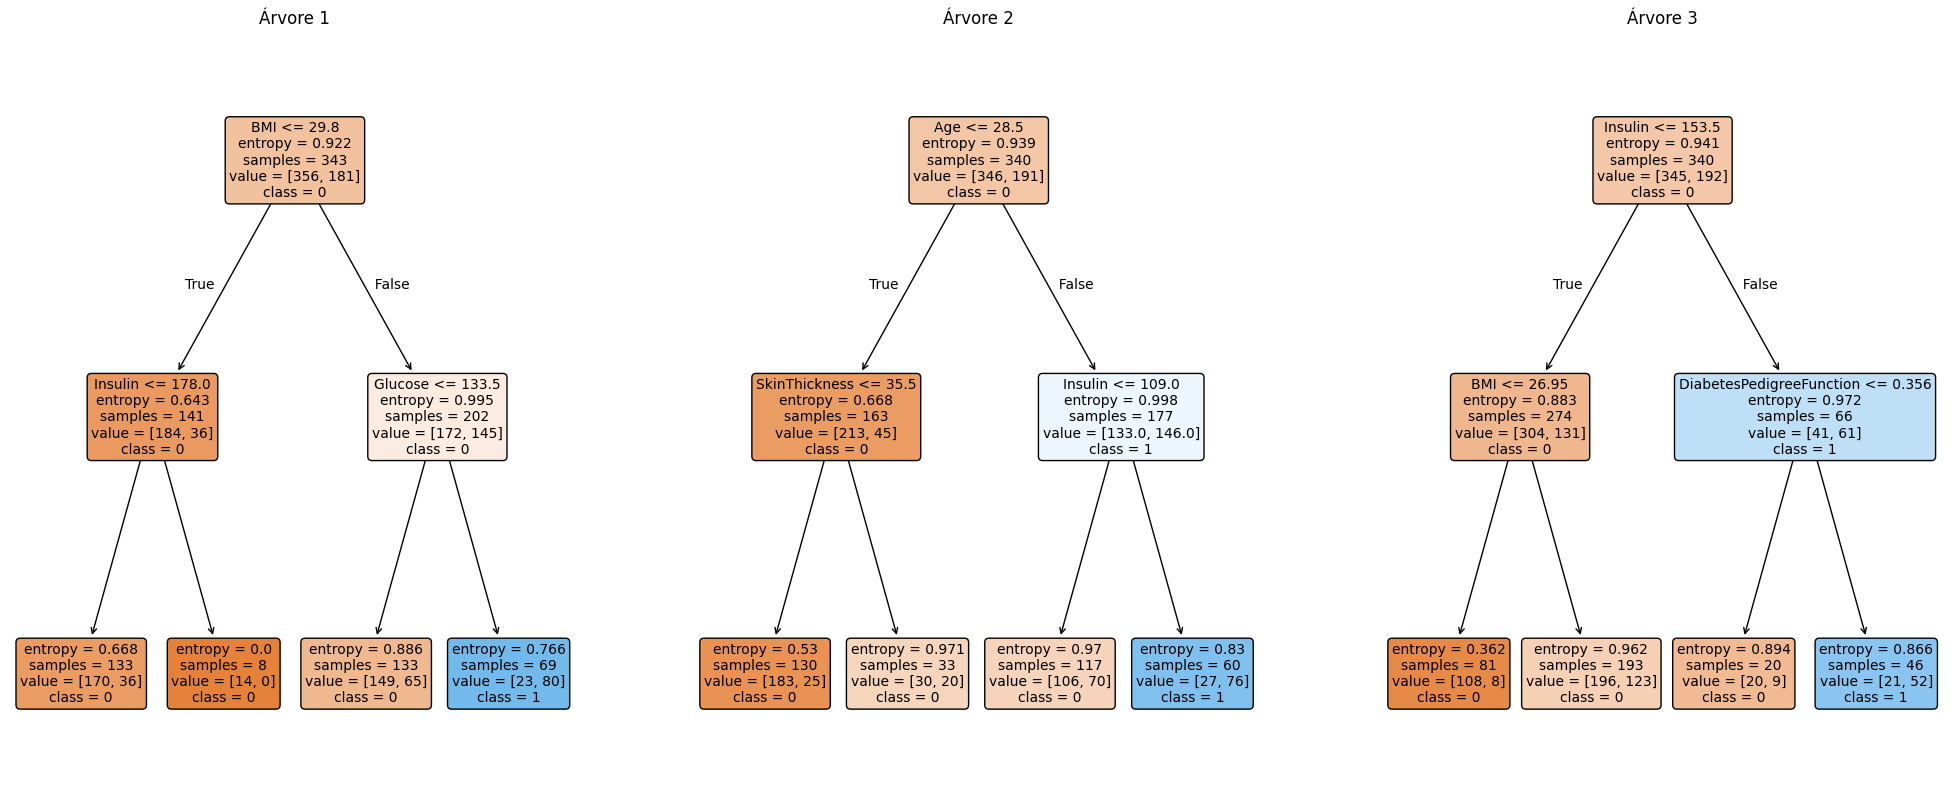

In [ ]:
#@title Codigo para Tarefa 3
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def random_forest_visual(df, target, criterio="entropy"):
    # Separar tipos de atributos
    atributos_numericos = df.drop(columns=[target]).select_dtypes(include=[np.number]).columns
    atributos_categoricos = df.drop(columns=[target]).select_dtypes(exclude=[np.number]).columns

    # One-hot encoding para atributos categóricos
    df_encoded = pd.get_dummies(df, drop_first=True)

    # Divisão treino/teste
    X = df_encoded.drop(columns=[col for col in df_encoded.columns if target in col])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Treinamento + tempo
    inicio = time.time()
    clf = RandomForestClassifier(n_estimators=3, max_depth=2, criterion=criterio, random_state=42)
    clf.fit(X_train, y_train)
    fim = time.time()

    # Acurácia
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Acurácia: {acc:.4f}")
    print(f"Tempo de execução: {fim - inicio:.4f} segundos")

    # Visualizar as 3 árvores
    fig, axes = plt.subplots(1, 3, figsize=(25, 10))
    for i, tree in enumerate(clf.estimators_):
        plot_tree(tree, feature_names=X.columns,
                  class_names=[str(c) for c in np.unique(y)],
                  filled=True, rounded=True, fontsize=10, ax=axes[i])
        axes[i].set_title(f"Árvore {i+1}")

    filename = f"random_forest_3trees_depth2_{criterio}.png"
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    print(f"As 3 árvores da Random Forest salvas em: {filename}")

    plt.show()

    return clf

# Exemplo de uso:
clf = random_forest_visual(df, target)


# **TAREFA 4**

Comparar várias técnicas de boost, opção da biblioteca

Dataset |Técnica | Acurária | Tempo
--|--|--|--
Adult | Adaboost |
Adult | Gradient Boost |
Adult | XGboost |
Adult | LightGBM |
Adult | Random Forest |
Diabetes | Adaboost |
Diabetes  | Gradient Boost |
Diabetes | XGboost |
Diabetes | LightGBM |
Diabetes | Random Forest |
Mushroom | Adaboost |
Mushroom | Gradient Boost |
Mushroom | XGboost |
Mushroom | LightGBM |
Mushroom | Random Forest |


In [ ]:
#@title Tarefa 4 - Avaliação sequencial de modelos
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Bibliotecas adicionais
from xgboost import XGBClassifier
import lightgbm as lgb

def avaliar_modelos(df, target, criterio="entropy"):
    # Separar tipos de atributos
    atributos_numericos = df.drop(columns=[target]).select_dtypes(include=[np.number]).columns
    atributos_categoricos = df.drop(columns=[target]).select_dtypes(exclude=[np.number]).columns

    # One-hot encoding para atributos categóricos
    df_encoded = pd.get_dummies(df, drop_first=True)

    # Divisão treino/teste
    X = df_encoded.drop(columns=[col for col in df_encoded.columns if target in col])
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y = le.fit_transform(df[target])


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    modelos = {
        "Random Forest": RandomForestClassifier(random_state=42),
        "AdaBoost": AdaBoostClassifier(random_state=42),

        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        "LightGBM": lgb.LGBMClassifier(random_state=42)
    }

    for nome, clf in modelos.items():
        print(f"\nTreinando modelo: {nome}")
        inicio = time.time()
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        fim = time.time()
        acc = accuracy_score(y_test, y_pred)
        print(f"Acurácia: {acc:.4f}")
        print(f"Tempo de execução: {fim - inicio:.4f} segundos")
# Exemplo de uso:
avaliar_modelos(df, target, criterio="entropy")



Treinando modelo: Random Forest
Acurácia: 1.0000
Tempo de execução: 6.8019 segundos

Treinando modelo: AdaBoost
Acurácia: 0.7184
Tempo de execução: 2.9299 segundos

Treinando modelo: Gradient Boosting
Acurácia: 0.9230
Tempo de execução: 12.9529 segundos

Treinando modelo: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:24:07] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Acurácia: 0.9997
Tempo de execução: 1.1870 segundos

Treinando modelo: LightGBM
[LightGBM] [Info] Number of positive: 23675, number of negative: 19073
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 963
[LightGBM] [Info] Number of data points in the train set: 42748, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.553827 -> initscore=0.216146
[LightGBM] [Info] Start training from score 0.216146
Acurácia: 0.9996
Tempo de execução: 1.0304 segundos


# **TAREFA 5**

Completar a tabela observando o mapa de calor para quantidade de árvores e profundidade para mostrar a acurácia com Random forest, xgboost, gradient boost e lightgbm.

Técnica | Dataset | Acurácia Mínima | Prof Mínima | Mínimo Árvore | tempo
--|--|--|--|--|--
Random | Mushroom | 92 |
XGboost | Mushroom | 92 |
XGboost | Mushroom | 99 |
Gradient boost | Mushroom | 92 |
lightgbm | Mushroom | 92 |
Random | Adult | 87 |
XGboost | Adult | 86 |
XGboost | Adult  | 87 |
Gradient boost | Adult  | 87 |
lightgbm | Mushroom | Adult  |







In [12]:
#@title Tarefa 5 - Mapas de calor de acurácia com valores
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from ipywidgets import widgets, interact

# Modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

# Codificar target
le = LabelEncoder()
y = le.fit_transform(df[target])

# One-hot encoding para atributos categóricos
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=[col for col in df_encoded.columns if target in col])

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Dropdown para escolher modelo
modelo_dropdown = widgets.Dropdown(
    options=['Random Forest', 'XGBoost', 'Gradient Boosting', 'LightGBM'],
    value='Random Forest',
    description='Modelo:'
)

def plot_heatmap(modelo_nome):
    n_estimators_list = [3, 6, 9, 12, 15]
    max_depth_list = [3, 6, 9, 12, 15]

    heatmap_acc = np.zeros((len(max_depth_list), len(n_estimators_list)))

    for i, depth in enumerate(max_depth_list):
        for j, n_tree in enumerate(n_estimators_list):
            if modelo_nome == 'Random Forest':
                clf = RandomForestClassifier(n_estimators=n_tree, max_depth=depth, random_state=42)
            elif modelo_nome == 'Gradient Boosting':
                clf = GradientBoostingClassifier(n_estimators=n_tree, max_depth=depth, random_state=42)
            elif modelo_nome == 'XGBoost':
                clf = XGBClassifier(n_estimators=n_tree, max_depth=depth, use_label_encoder=False,
                                    eval_metric='logloss', random_state=42)
            elif modelo_nome == 'LightGBM':
                clf = lgb.LGBMClassifier(n_estimators=n_tree, max_depth=depth, random_state=42)

            inicio = time.time()
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            fim = time.time()
            acc = accuracy_score(y_test, y_pred)
            heatmap_acc[i, j] = acc
            print(f"{modelo_nome} | Árvores: {n_tree}, Profundidade: {depth} -> Acurácia: {acc:.4f}, Tempo: {fim-inicio:.2f}s")

    # Plot
    plt.figure(figsize=(9,7))
    im = plt.imshow(heatmap_acc, origin='lower', cmap='YlGnBu', extent=[min(n_estimators_list)-1, max(n_estimators_list)+1,
                                                                       min(max_depth_list)-1, max(max_depth_list)+1])

    # Adicionar os valores da acurácia sobre as células
    for i, depth in enumerate(max_depth_list):
        for j, n_tree in enumerate(n_estimators_list):
            plt.text(n_tree, depth, f"{heatmap_acc[i, j]:.2f}", ha='center', va='center', color='black', fontsize=10)

    plt.colorbar(im, label='Acurácia')
    plt.xticks(n_estimators_list)
    plt.yticks(max_depth_list)
    plt.xlabel('Número de Árvores (n_estimators)')
    plt.ylabel('Profundidade Máxima (max_depth)')
    plt.title(f'Mapa de Calor de Acurácia - {modelo_nome}')
    plt.show()

interact(plot_heatmap, modelo_nome=modelo_dropdown)


interactive(children=(Dropdown(description='Modelo:', options=('Random Forest', 'XGBoost', 'Gradient Boosting'…

<function __main__.plot_heatmap(modelo_nome)>

# **TAREFA 6**

Veja a importância das variáveis para cada técnica
* colocar a variavel e seu peso para as três mais importantes
* Pode abreviar

Técnica | Dataset | Arvores | Prof | Acu | Top1+peso | Top2+peso | Top3+peso
--|--|--|--|--|--|--|--
Random Forest | Mushroom | 3 |3 |
Xgboost | Mushroom | 3 |3 |
Gradient | Mushroom | 3 |3 |
Lightgbm | Mushroom | 3 |3 |
Random Forest | Mushroom | 9 |9 |
Xgboost | Mushroom | 9 |9 |
Gradient | Mushroom | 9 |9 |
Lightgbm | Mushroom | 9 |9 |
Random Forest | Adults | 9 |9 |
Xgboost | Adults | 9 |9 |
Gradient | Adults | 9 |9 |
Lightgbm | Adults  | 9 |9 |
Random Forest | Diabetes |6 | 6 |
Xgboost | Diabetes | 6 | 6 |
Gradient |Diabetes  | 6 | 6 |
Lightgbm | Diabetes  | 6 | 6 |


In [ ]:
#@title Tarefa 6 - Acurácia + Top 5 Importância das Variáveis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from ipywidgets import widgets, interact

# Modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

# Codificar target
le = LabelEncoder()
y = le.fit_transform(df[target])

# One-hot encoding para atributos categóricos
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=[col for col in df_encoded.columns if target in col])

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Dropdowns
modelo_dropdown = widgets.Dropdown(
    options=['Random Forest', 'XGBoost', 'Gradient Boosting', 'LightGBM'],
    value='Random Forest', description='Modelo:'
)
n_estimators_dropdown = widgets.Dropdown(
    options=[3, 6, 9, 12, 15], value=9, description='Árvores:'
)
max_depth_dropdown = widgets.Dropdown(
    options=[3, 6, 9, 12, 15], value=9, description='Profundidade:'
)

def avaliar_modelo(modelo_nome, n_estimators, max_depth):
    # Seleção do modelo
    if modelo_nome == 'Random Forest':
        clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    elif modelo_nome == 'Gradient Boosting':
        clf = GradientBoostingClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    elif modelo_nome == 'XGBoost':
        clf = XGBClassifier(n_estimators=n_estimators, max_depth=max_depth,
                            use_label_encoder=False, eval_metric='logloss', random_state=42)
    else:  # LightGBM
        clf = lgb.LGBMClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)

    inicio = time.time()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    fim = time.time()
    acc = accuracy_score(y_test, y_pred)
    print(f"Acurácia: {acc:.4f} (Tempo: {fim-inicio:.2f}s)")

    # Importância das variáveis (Top 5)
    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
        sorted_idx = np.argsort(importances)[::-1][:5]  # só 5 maiores
        top_features = X.columns[sorted_idx]
        top_importances = importances[sorted_idx]

        # Tabela com top 5
        display(pd.DataFrame({'Variável': top_features, 'Importância': top_importances}))

        # Plot
        plt.figure(figsize=(7,4))
        plt.barh(top_features[::-1], top_importances[::-1])
        plt.xlabel('Importância')
        plt.title('Top 5 Importância das Variáveis')
        plt.tight_layout()
        plt.show()
    else:
        print("Este modelo não possui atributo feature_importances_.")

interact(
    avaliar_modelo,
    modelo_nome=modelo_dropdown,
    n_estimators=n_estimators_dropdown,
    max_depth=max_depth_dropdown
)


interactive(children=(Dropdown(description='Modelo:', options=('Random Forest', 'XGBoost', 'Gradient Boosting'…

<function __main__.avaliar_modelo(modelo_nome, n_estimators, max_depth)>

# **TAREFA 7**

Agora execute novamente, selecione trẽs atributos para cada um dos dataset, a acurácia melhorou ?

**Complete para menor configuração de árvore e profundidade**

1. Diabetes, técnica= ..., atributos= ...., acurácia= ...., qte de nós= ...
2. Adults, técnica= ..., atributos= ...., acurácia= ....qte de nós= ...
3. Mushroom, técnica= ..., atributos= ...., acurácia= ....qte de nós= ...

**Complete para maior configuração de árvore e profundidade**

1. Diabetes, técnica= ..., atributos= ...., acurácia= ....qte de nós= ...
2. Adults, técnica= ..., atributos= ...., acurácia= ....qte de nós= ...
3. Mushroom, técnica= ..., atributos= ...., acurácia= ....qte de nós= ...

**Complete para "melhor" configuração de árvore e profundidade**

1. Diabetes, técnica= ..., atributos= ...., acurácia= ...., árvores = ..., profundidade = ....qte de nós= ...
2. Adults, técnica= ..., atributos= ...., acurácia= ....árvores = ..., profundidade = ....qte de nós= ...
3. Mushroom, técnica= ..., atributos= ...., acurácia= ....árvores = ..., profundidade = ....qte de nós= ...

A "melhor", usar sua intuição para ter um bom balanço de não usar muitas árvores nem árvores muito profundas e obter uma boa acurácia perto do máximo.

In [20]:
#@title Tarefa 7 - Acurácia + Total de Nós + Seleção 3 Features
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from ipywidgets import widgets, interact

# Modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

# =================== Função para contar nós ===================
def count_total_nodes(clf, modelo_nome):
    """
    Retorna o total de nós (internos + folhas) de todas as árvores do classificador.
    Funciona para RandomForest, GradientBoosting (sklearn),
    XGBoost (sklearn wrapper) e LightGBM (sklearn wrapper).
    """
    total_nos = None

    if modelo_nome == 'Random Forest':
        # estimators_ é uma lista de árvores
        total_nos = sum(est.tree_.node_count for est in clf.estimators_)

    elif modelo_nome == 'Gradient Boosting':
        # estimators_ é um ndarray shape (n_estimators, n_classes)
        estimators = np.ravel(clf.estimators_)
        total_nos = sum(est.tree_.node_count for est in estimators)

    elif modelo_nome == 'XGBoost':
        try:
            booster = clf.get_booster()
        except Exception:
            booster = getattr(clf, 'booster_', None)
        if booster is None:
            return None
        # trees_to_dataframe: cada linha = 1 nó
        try:
            df_trees = booster.trees_to_dataframe()
            total_nos = int(df_trees.shape[0])
        except Exception:
            # fallback: contar linhas do dump textual de cada árvore
            dump = booster.get_dump()
            total_nos = sum(len(d.splitlines()) for d in dump)

    elif modelo_nome == 'LightGBM':
        booster = getattr(clf, 'booster_', None)
        if booster is None:
            booster = clf.booster_
        model_dump = booster.dump_model()
        # contar nós recursivamente
        def count_nodes(node):
            if 'left_child' in node and 'right_child' in node:
                return 1 + count_nodes(node['left_child']) + count_nodes(node['right_child'])
            else:
                return 1
        total_nos = sum(count_nodes(tree['tree_structure']) for tree in model_dump['tree_info'])

    return total_nos
# =============================================================

# Codificar target
le = LabelEncoder()
y = le.fit_transform(df[target])

# One-hot encoding para atributos categóricos
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=[col for col in df_encoded.columns if target in col])

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Dropdowns
modelo_dropdown = widgets.Dropdown(
    options=['Random Forest', 'XGBoost', 'Gradient Boosting', 'LightGBM'],
    value='Random Forest', description='Modelo:'
)
n_estimators_dropdown = widgets.Dropdown(
    options=[3, 6, 9, 12, 15], value=9, description='Árvores:'
)
max_depth_dropdown = widgets.Dropdown(
    options=[3, 6, 9, 12, 15], value=9, description='Profundidade:'
)

feature_dropdown1 = widgets.Dropdown(options=X.columns, description='Feature 1:')
feature_dropdown2 = widgets.Dropdown(options=X.columns, description='Feature 2:')
feature_dropdown3 = widgets.Dropdown(options=X.columns, description='Feature 3:')

def avaliar_modelo(modelo_nome, n_estimators, max_depth):
    """Treina com todas as variáveis e mostra top5 importâncias."""
    if modelo_nome == 'Random Forest':
        clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    elif modelo_nome == 'Gradient Boosting':
        clf = GradientBoostingClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    elif modelo_nome == 'XGBoost':
        clf = XGBClassifier(n_estimators=n_estimators, max_depth=max_depth,
                            use_label_encoder=False, eval_metric='logloss', random_state=42)
    else:  # LightGBM
        clf = lgb.LGBMClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Acurácia com todas as variáveis: {acc:.4f}")

    # Contar nós
    total_nos = count_total_nodes(clf, modelo_nome)
    print(f"Total de nós de todas as árvores: {total_nos}")

    # Importância das variáveis (Top 5)
    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
        sorted_idx = np.argsort(importances)[::-1][:5]  # Top 5
        top_features = X.columns[sorted_idx]
        top_importances = importances[sorted_idx]
        display(pd.DataFrame({'Variável': top_features, 'Importância': top_importances}))

        plt.figure(figsize=(7,4))
        plt.barh(top_features[::-1], top_importances[::-1])
        plt.xlabel('Importância')
        plt.title('Top 5 Importância das Variáveis')
        plt.tight_layout()
        plt.show()

def treinar_com_selecionadas(feature1, feature2, feature3, modelo_nome, n_estimators, max_depth):
    """Treina só com 3 features escolhidas e mostra acurácia + total de nós."""
    features = [feature1, feature2, feature3]
    print(f"\nTreinando apenas com: {features}")

    X_train_sel = X_train[features]
    X_test_sel = X_test[features]

    if modelo_nome == 'Random Forest':
        clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    elif modelo_nome == 'Gradient Boosting':
        clf = GradientBoostingClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    elif modelo_nome == 'XGBoost':
        clf = XGBClassifier(n_estimators=n_estimators, max_depth=max_depth,
                            use_label_encoder=False, eval_metric='logloss', random_state=42)
    else:  # LightGBM
        clf = lgb.LGBMClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)

    clf.fit(X_train_sel, y_train)
    y_pred = clf.predict(X_test_sel)
    acc = accuracy_score(y_test, y_pred)
    print(f"Acurácia com apenas essas 3 variáveis: {acc:.4f}")

    # Contar nós
    total_nos = count_total_nodes(clf, modelo_nome)
    print(f"Total de nós de todas as árvores: {total_nos}")

# Primeiro interativo: mostra top5 e total de nós
interact(avaliar_modelo,
         modelo_nome=modelo_dropdown,
         n_estimators=n_estimators_dropdown,
         max_depth=max_depth_dropdown)

# Segundo interativo: treina com 3 escolhidas
interact(treinar_com_selecionadas,
         feature1=feature_dropdown1,
         feature2=feature_dropdown2,
         feature3=feature_dropdown3,
         modelo_nome=modelo_dropdown,
         n_estimators=n_estimators_dropdown,
         max_depth=max_depth_dropdown)


interactive(children=(Dropdown(description='Modelo:', options=('Random Forest', 'XGBoost', 'Gradient Boosting'…

interactive(children=(Dropdown(description='Feature 1:', options=('age', 'fnlwgt', 'educational-num', 'capital…

<function __main__.treinar_com_selecionadas(feature1, feature2, feature3, modelo_nome, n_estimators, max_depth)>